<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-3-experiment-1/brfss_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Baseline Algorithm Comparison (CDC BRFSS)

This notebook trains and compares three baseline machine learning models on the **raw, unbalanced CDC BRFSS dataset**:

1. Logistic Regression  
2. LightGBM  
3. XGBoost  

The purpose of this experiment is to establish baseline performance before applying any balancing techniques such as SMOTE.

## Evaluation Metrics
The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC

## Dataset
- **Dataset:** CDC BRFSS Diabetes Health Indicators
- **Target column:** `Diabetes_binary`

## Notes
- The dataset remains **unbalanced** in this experiment.
- A **stratified 80/20 train-test split** is used.
- **Feature scaling** is applied only for Logistic Regression.

In [9]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 372, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 372 (delta 58), reused 15 (delta 15), pack-reused 256 (from 4)
Receiving objects: 100% (372/372), 9.89 MiB | 23.39 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [10]:
import os
os.chdir("/content/Predicting-Type-2-Diabetes")
print("Current working directory:", os.getcwd())

Current working directory: /content/Predicting-Type-2-Diabetes


In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [12]:
os.makedirs("results", exist_ok=True)
print("Results folder ready.")

Results folder ready.


In [13]:
df = pd.read_csv("data/raw/diabetes_binary_health_indicators_BRFSS2015.csv")

print("CDC BRFSS dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

CDC BRFSS dataset loaded successfully.
Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution (count):")
print(df["Diabetes_binary"].value_counts())

print("\nTarget distribution (%):")
print(df["Diabetes_binary"].value_counts(normalize=True) * 100)

Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:
0

Duplicate rows:
24206

Target distribution (count):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Target distribution (%):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


In [15]:
class_counts = df["Diabetes_binary"].value_counts().sort_index()
no_diabetes = class_counts[0]
diabetes = class_counts[1]

no_diabetes_pct = (no_diabetes / len(df)) * 100
diabetes_pct = (diabetes / len(df)) * 100
imbalance_ratio = no_diabetes / diabetes

print("Imbalance Severity Note")
print(f"No Diabetes (0): {no_diabetes:,} ({no_diabetes_pct:.2f}%)")
print(f"Diabetes (1): {diabetes:,} ({diabetes_pct:.2f}%)")
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

Imbalance Severity Note
No Diabetes (0): 218,334 (86.07%)
Diabetes (1): 35,346 (13.93%)
Majority-to-minority ratio: 6.18:1


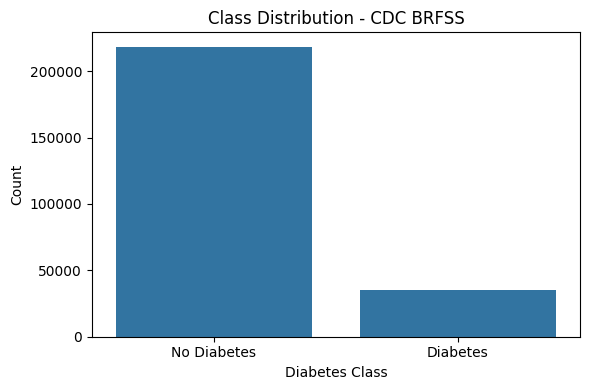

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes_binary", data=df)
plt.title("Class Distribution - CDC BRFSS")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.tight_layout()
plt.savefig("results/brfss_class_distribution_baseline.png", dpi=150)
plt.show()

In [17]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (202944, 21)
Test shape: (50736, 21)

Train target distribution:
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Test target distribution:
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete for Logistic Regression.")

Scaling complete for Logistic Regression.


In [20]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc
    }

In [21]:
## 1. Logistic Regression

In [23]:
print("-" * 50)
print("Training Logistic Regression")
print("-" * 50)

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")

--------------------------------------------------
Training Logistic Regression
--------------------------------------------------
Logistic Regression trained successfully.


In [24]:
lr_results = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)

--- Logistic Regression Evaluation ---
Accuracy : 0.8621
Precision: 0.5171
Recall   : 0.1583
F1-Score : 0.2424
AUC-ROC  : 0.8192

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



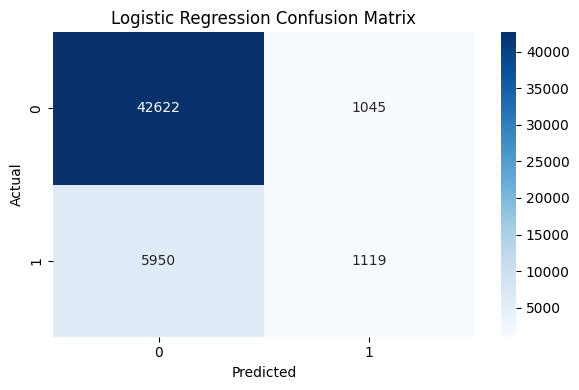

In [25]:
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/brfss_lr_confusion_matrix_baseline.png", dpi=150)
plt.show()

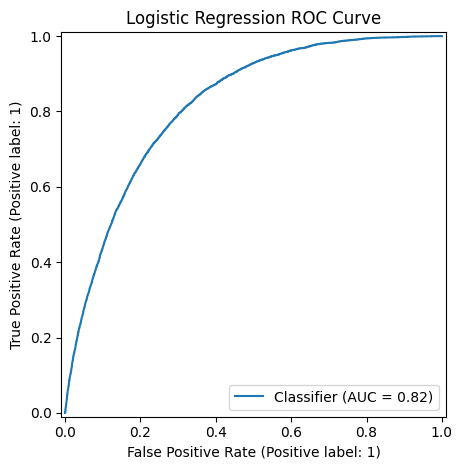

In [26]:
RocCurveDisplay.from_predictions(y_test, lr_prob)
plt.title("Logistic Regression ROC Curve")
plt.tight_layout()
plt.savefig("results/brfss_lr_roc_curve_baseline.png", dpi=150)
plt.show()

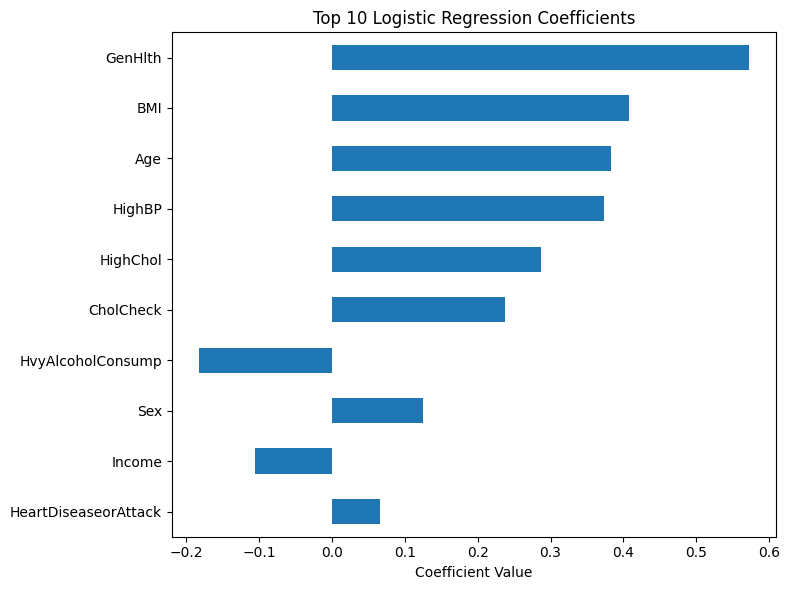

Top 10 Logistic Regression Coefficients:
GenHlth                 0.572245
BMI                     0.408314
Age                     0.382325
HighBP                  0.373808
HighChol                0.286321
CholCheck               0.237584
HvyAlcoholConsump      -0.181784
Sex                     0.125662
Income                 -0.105203
HeartDiseaseorAttack    0.065403
dtype: float64


In [27]:
lr_coefficients = pd.Series(
    lr_model.coef_[0],
    index=X.columns
).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
lr_coefficients.head(10).plot(kind="barh")
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("results/brfss_lr_coefficients_baseline.png", dpi=150)
plt.show()

print("Top 10 Logistic Regression Coefficients:")
print(lr_coefficients.head(10))

## 2. LightGBM

In [28]:
print("-" * 50)
print("Training LightGBM")
print("-" * 50)

lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

print("LightGBM trained successfully.")

--------------------------------------------------
Training LightGBM
--------------------------------------------------
LightGBM trained successfully.


In [29]:
lgbm_results = evaluate_model("LightGBM", y_test, lgbm_pred, lgbm_prob)

--- LightGBM Evaluation ---
Accuracy : 0.8655
Precision: 0.5591
Recall   : 0.1640
F1-Score : 0.2536
AUC-ROC  : 0.8269

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.56      0.16      0.25      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



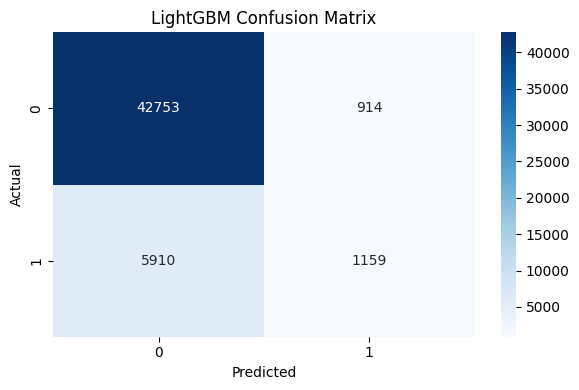

In [30]:
lgbm_cm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(lgbm_cm, annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/brfss_lgbm_confusion_matrix_baseline.png", dpi=150)
plt.show()

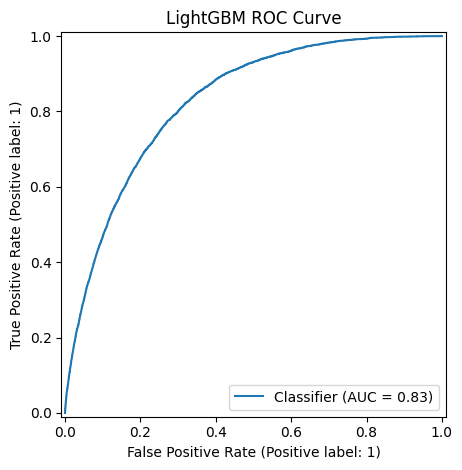

In [31]:
RocCurveDisplay.from_predictions(y_test, lgbm_prob)
plt.title("LightGBM ROC Curve")
plt.tight_layout()
plt.savefig("results/brfss_lgbm_roc_curve_baseline.png", dpi=150)
plt.show()

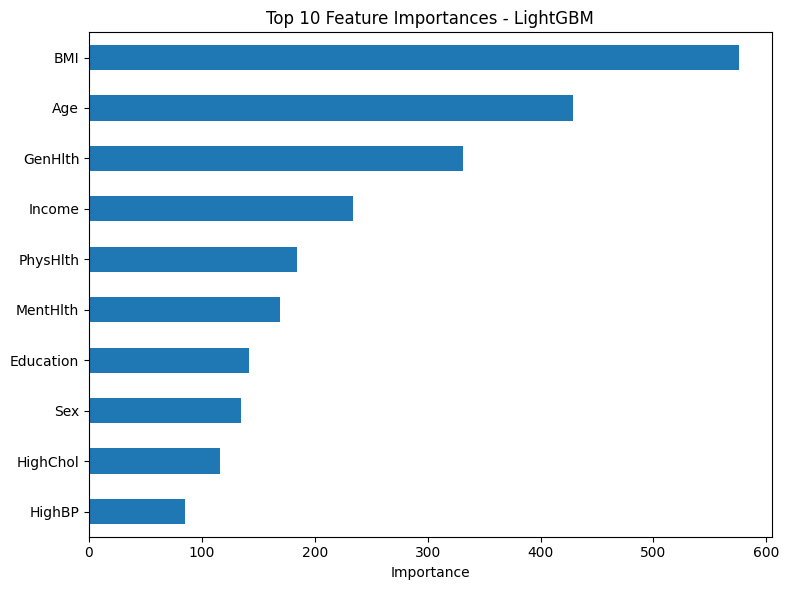

Top 10 LightGBM Feature Importances:
BMI          576
Age          429
GenHlth      331
Income       234
PhysHlth     184
MentHlth     169
Education    142
Sex          135
HighChol     116
HighBP        85
dtype: int32


In [32]:
lgbm_importances = pd.Series(
    lgbm_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
lgbm_importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("results/brfss_lgbm_feature_importance_baseline.png", dpi=150)
plt.show()

print("Top 10 LightGBM Feature Importances:")
print(lgbm_importances.head(10))

## 3. XGBoost

In [33]:
print("-" * 50)
print("Training XGBoost")
print("-" * 50)

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully.")

--------------------------------------------------
Training XGBoost
--------------------------------------------------
XGBoost trained successfully.


In [34]:
xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

--- XGBoost Evaluation ---
Accuracy : 0.8655
Precision: 0.5583
Recall   : 0.1654
F1-Score : 0.2552
AUC-ROC  : 0.8272

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.56      0.17      0.26      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



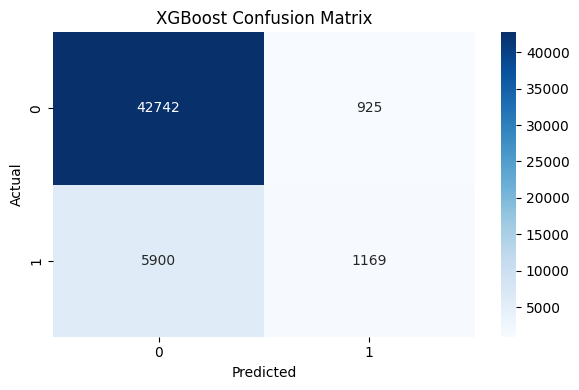

In [35]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/brfss_xgb_confusion_matrix_baseline.png", dpi=150)
plt.show()

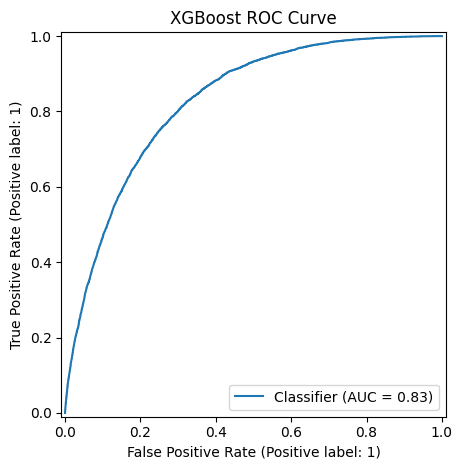

In [36]:
RocCurveDisplay.from_predictions(y_test, xgb_prob)
plt.title("XGBoost ROC Curve")
plt.tight_layout()
plt.savefig("results/brfss_xgb_roc_curve_baseline.png", dpi=150)
plt.show()

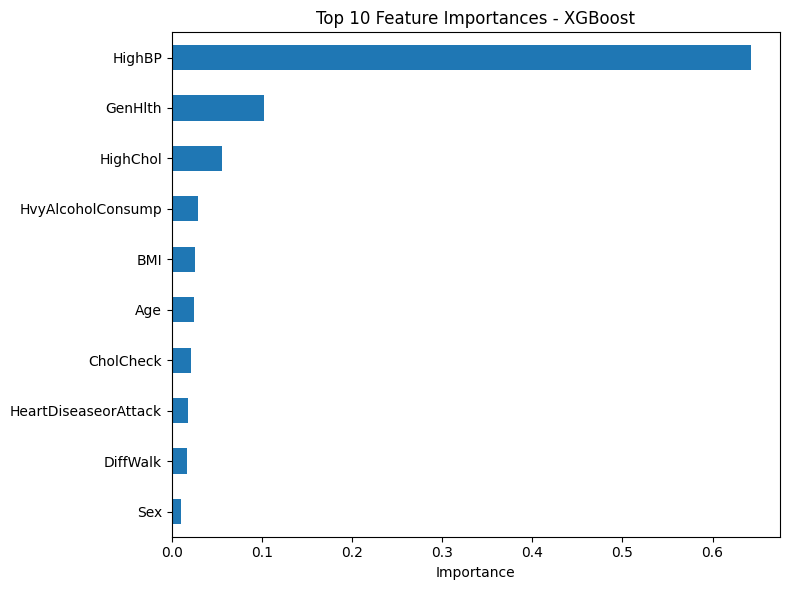

Top 10 XGBoost Feature Importances:
HighBP                  0.642648
GenHlth                 0.102621
HighChol                0.055519
HvyAlcoholConsump       0.029218
BMI                     0.025421
Age                     0.025045
CholCheck               0.021753
HeartDiseaseorAttack    0.017849
DiffWalk                0.016755
Sex                     0.010112
dtype: float32


In [37]:
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
xgb_importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("results/brfss_xgb_feature_importance_baseline.png", dpi=150)
plt.show()

print("Top 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))

In [38]:
results_df = pd.DataFrame([lr_results, lgbm_results, xgb_results])
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("Baseline Model Comparison:")
results_df

Baseline Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,XGBoost,0.865480,0.558262,0.165370,0.255157,0.827230
1,LightGBM,0.865500,0.559093,0.163955,0.253555,0.826911
2,Logistic Regression,0.862129,0.517098,0.158297,0.242391,0.819163


In [39]:
results_df.to_csv("results/brfss_baseline_model_comparison.csv", index=False)
print("Comparison table saved successfully.")

Comparison table saved successfully.


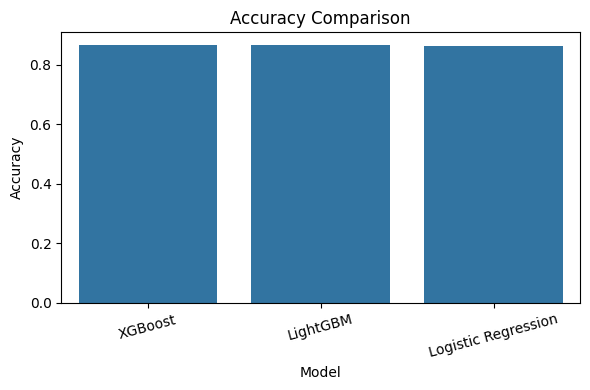

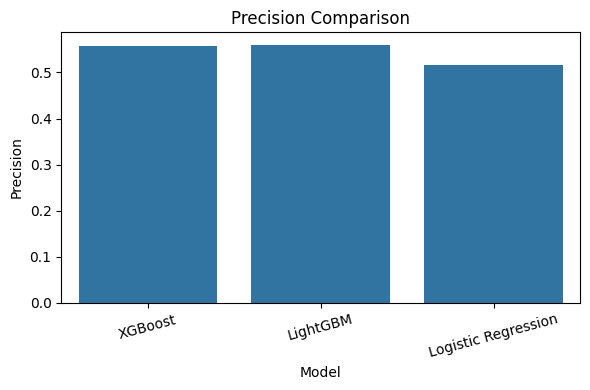

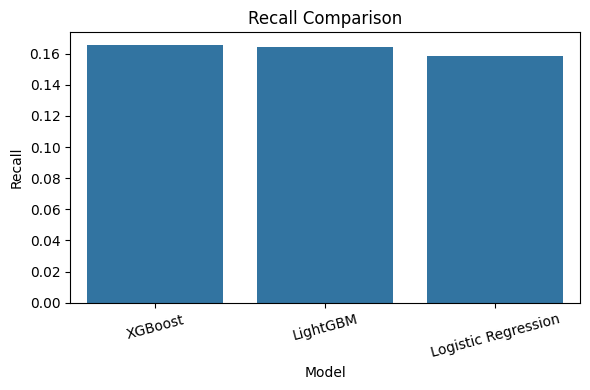

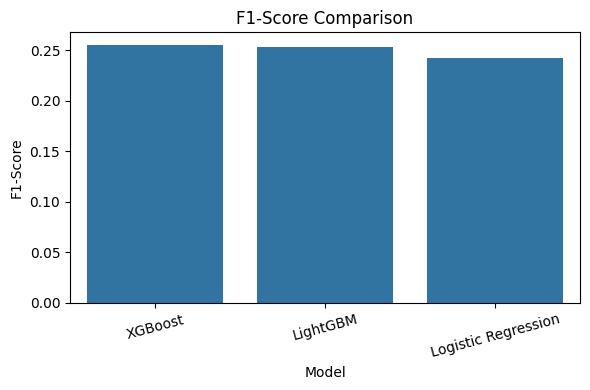

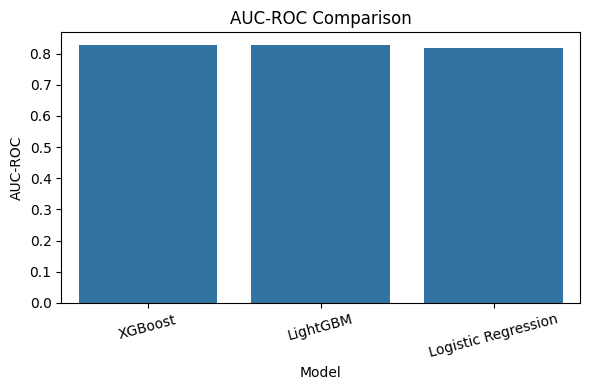

In [40]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=results_df, x="Model", y=metric)
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"results/brfss_{metric.lower().replace('-', '_')}_comparison_baseline.png", dpi=150)
    plt.show()

In [41]:
best_model = results_df.iloc[0]

print("Best Baseline Model Based on F1-Score")
print("-------------------------------------")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1-Score  : {best_model['F1-Score']:.4f}")
print(f"AUC-ROC   : {best_model['AUC-ROC']:.4f}")

Best Baseline Model Based on F1-Score
-------------------------------------
Model     : XGBoost
Accuracy  : 0.8655
Precision : 0.5583
Recall    : 0.1654
F1-Score  : 0.2552
AUC-ROC   : 0.8272


## Final Notes

This experiment established baseline performance for three models on the **raw, unbalanced CDC BRFSS dataset**.

### Key points:
- No balancing techniques were used.
- The dataset remained in its original imbalanced form.
- Logistic Regression used scaled features.
- LightGBM and XGBoost used the original tabular features.
- The final comparison table can be used in the project report to discuss which model performed best under baseline conditions.